In [53]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import matplotlib.pyplot as plt
from scripts.constants import *

In [54]:
class Lattice:
    def __init__(self, X, Y=None,
                 pbc_x=False, pbc_y=True):
        self.X = X
        Y = X if Y is None else Y
        self.Y = Y
        self.pbc_x=pbc_x
        self.pbc_y=pbc_y
        self.num_sites = X * Y

        edges_x = []
        edges_y = []
        for y in range(Y):
            for x in range(X):
                i = y * X + x  # flat index for (x,y)

                # right neighbor (x+1, y)
                if x < X - 1:
                    edges_x.append((i, i + 1))
                elif pbc_x and X > 2:
                    edges_x.append((i, y * X))

                # down neighbor (x, y+1)
                if y < Y - 1:
                    edges_y.append((i, (y + 1) * X + x))
                elif pbc_y and Y > 2:
                    edges_y.append((i, x))
        self.edges_y = edges_y
        self.edges_x = edges_x

    def get_coords(self, i):
        y = i // self.X
        x = i % self.X
        return np.asarray([x, y], dtype=int)

    def get_disp(self, i, j):
        ri = self.get_coords(i)  # [xi, yi]
        rj = self.get_coords(j)  # [xj, yj]
        dr = np.subtract(rj, ri) # [dx, dy]

        Lx, Ly = self.X, self.Y
        if self.pbc_x:
            if dr[0] > Lx // 2:
                dr[0] -= Lx
            elif dr[0] < -Lx // 2:
                dr[0] += Lx

        if self.pbc_y:
            if dr[1] > Ly // 2:
                dr[1] -= Ly
            elif dr[1] < -Ly // 2:
                dr[1] += Ly

        return dr
    
    def get_dir(self, i, j):
        dr = self.get_disp(i, j)
        if dr[0] == 1 and dr[1] == 0:
            return "+x"
        elif dr[0] == -1 and dr[1] == 0:
            return "-x"
        elif dr[0] == 0 and dr[1] == 1:
            return "+y"
        elif dr[0] == 0 and dr[1] == -1:
            return "-y"
        
    def get_edge_and_bulk_indices(X, Y, edge_width=1):
        edge_indices = []
        bulk_indices = []

        for y in range(Y):
            for x in range(X):
                i = y * X + x  # flattened index

                if x < edge_width or x >= X - edge_width or y < edge_width or y >= Y - edge_width:
                    edge_indices.append(i)
                else:
                    bulk_indices.append(i)

        return edge_indices, bulk_indices

    def plot(self, highlight=None, path=None):
        fig, ax = plt.subplots(figsize=(6, 6))
        coords = {}

        for y in range(self.Y):
            for x in range(self.X):
                i = y * self.X + x
                coords[i] = (x, -y)

        for i, j in self.edges_x + self.edges_y:
            x1, y1 = coords[i]
            x2, y2 = coords[j]
            ax.plot([x1, x2], [y1, y2], 'k-', lw=1)

        for i, (xx, yy) in coords.items():
            ax.plot(xx, yy, 'ro')
            ax.text(xx, yy, str(i), fontsize=10, ha='center', va='center',
                    color="white", bbox=dict(facecolor="black",
                                             edgecolor="none",
                                             boxstyle="circle,pad=0.25"))
            if highlight is not None and i in highlight:
                ax.plot(xx, yy, 'ro')
                ax.text(xx, yy, str(i), fontsize=10, ha='center', va='center',
                        color="black", bbox=dict(facecolor="red",
                                                edgecolor="none",
                                                boxstyle="circle,pad=0.25"))

        ax.set_aspect("equal")
        ax.axis("off")
        if path is not None:
            plt.savefig(path, bbox_inches='tight')
        plt.show()


In [55]:
def delta(x, eta=1e-6): # Lorentzian approximation of delta function
    return eta / (PI * (eta**2 + x**2))

def lorentzian(x, eta=1e-6):
    return eta / (PI * (x**2 + eta**2))

def fermi_dirac(energy, T=1e-6):
    if T == 0:
        return np.zeros_like(energy)
    else:
        return 1.0 / (np.exp((energy) / T) + 1.0)

def is_hermitian(matrix, atol=1e-8, rtol=1e-6):
    is_hermitian = np.allclose(matrix, matrix.conj().T, rtol=rtol, atol=atol)
    return is_hermitian


In [ ]:
class Hamiltonian:
    def __init__(self, t, mu, lattice,
                 U=None, V=None, V_prime=None,
                 F0_init = 0, F_init = np.zeros(4),
                 Fuu_init = np.zeros(4), 
                 Fdd_init = np.zeros(4)):
        
        '''
        Builds k-independent Hamiltonian matrix 
        '''
        self.t = t 
        self.mu = mu
        self.lattice = lattice
        Nx = lattice.X
        self.dim = 4 * Nx

        if U is None:
            U = np.zeros(Nx)
        if V is None:
            V = np.zeros(Nx-1)
        if V_prime is None:
            V_prime = np.zeros(Nx-1)
        self.U = U
        self.V = V
        self.V_prime = V_prime

        self.F0 = np.ones(Nx, dtype=np.complex128) * F0_init
        
        self.Fx_plus = np.ones(Nx-1, dtype=np.complex128) * F_init[0]
        self.Fx_min = np.ones(Nx-1, dtype=np.complex128) * F_init[1]
        self.Fy_plus = np.ones(Nx, dtype=np.complex128) * F_init[2]
        self.Fy_min = np.ones(Nx, dtype=np.complex128) * F_init[3]
        self.Fuu_xplus = np.ones(Nx-1, dtype=np.complex128) * Fuu_init[0]
        self.Fuu_xmin = np.ones(Nx-1, dtype=np.complex128) * Fuu_init[1]
        self.Fuu_yplus = np.ones(Nx, dtype=np.complex128) * Fuu_init[2]
        self.Fuu_ymin = np.ones(Nx, dtype=np.complex128) * Fuu_init[3]

        self.Fdd_xplus = np.ones(Nx-1, dtype=np.complex128) * Fdd_init[0]
        self.Fdd_xmin = np.ones(Nx-1, dtype=np.complex128) * Fdd_init[1]
        self.Fdd_yplus = np.ones(Nx, dtype=np.complex128) * Fdd_init[2]
        self.Fdd_ymin = np.ones(Nx, dtype=np.complex128) * Fdd_init[3]
        
        gap0 = U * self.F0
        gap1 = V[:-1] * self.Fx_min
        gap2 = V[:-1] * self.Fx_plus
        gap1_uu = V_prime[:-1] * self.Fuu_xmin
        gap2_uu = V_prime[:-1] * self.Fuu_xplus
        gap1_dd = V_prime[:-1] * self.Fuu_xmin
        gap2_dd = V_prime[:-1] * self.Fuu_xplus
        
        self.matrix = np.zeros((self.dim, self.dim), dtype=np.complex128)
        
        diag = - mu #- 2.0 * t *cos(0)
        # set in diagonal elements (mu + 2cos(0))
        for i in range(lattice.X):
            sl = slice(4 * i, 4 * i + 4)
            self.matrix[sl,sl] += np.diag(np.array(
                [diag, diag, -diag, -diag]
            ))

            # set in BCS gap
            block = np.zeros((4, 4), dtype=np.complex128)
            block[0, 3] = gap0[i]
            block[1, 2] = -gap0[i].conj()
            block[2, 1] = -gap0[i].conj()
            block[3, 0] = gap0[i]
            self.matrix[sl,sl] += block

        # set in hopping block in x direction
        for i in range(Nx-1):
            idx = i % (Nx-1)
            sli = slice(4 * i, 4 * i + 4)
            slj = slice(4 * (i + 1), 4 * (i + 1) + 4)
            self.matrix[sli,slj] += np.diag(np.array(
                [-t, -t, t, t]
            ))
            self.matrix[slj,sli] += np.diag(np.array(
                [-t, -t, t, t]
            ))

            # x+
            upper = np.zeros((4, 4), dtype=np.complex128)
          
            upper[0, 3] = gap2[idx]
            upper[1, 2] = -gap1[idx]
            upper[2, 1] = -gap2[idx].conj()
            upper[3, 0] = gap1[idx].conj()

            upper[0, 2] = gap2_uu[idx]
            upper[1, 3] = gap2_dd[idx]
            upper[2, 0] = gap1_uu[idx].conj()
            upper[3, 1] = gap1_dd[idx].conj()

            # x-
            lower = np.zeros((4, 4), dtype=np.complex128)
            lower[0, 3] = gap1[idx]
            lower[1, 2] = -gap2[idx]
            lower[2, 1] = -gap1[idx].conj()
            lower[3, 0] = gap2[idx].conj()

            lower[0, 2] = gap1_uu[idx]
            lower[1, 3] = gap1_dd[idx]
            lower[2, 0] = gap2_uu[idx].conj()
            lower[3, 1] = gap2_dd[idx].conj()

            self.matrix[sli, slj] += upper
            self.matrix[slj, sli] += lower

    def is_hermitian(self, atol=1e-8, rtol=1e-6):
        if self.matrix is None:
            raise RuntimeError("Hamiltonian matrix not built yet. "
                               "Call build() first.")
        is_hermitian = np.allclose(self.matrix, self.matrix.conj().T, rtol=rtol, atol=atol)
        return is_hermitian

    def get_dim(self):
        return self.dim
    
    def build_Hk(self, k):
        Hk = np.zeros((self.get_dim(), self.get_dim()), dtype=np.complex128)
        
        eps = -2.0 * self.t * np.cos(k)
        gap_y1 = self.V * (self.Fy_plus * np.exp(-1j*k) +
                           self.Fy_min * np.exp(1j*k)) 
        gap_y2 = self.V * (self.Fy_plus * np.exp(1j*k) +
                            self.Fy_min * np.exp(-1j*k))

        gap_uu_y = self.V_prime * (self.Fuu_yplus * np.exp(-1j*k) +
                                   self.Fuu_ymin * np.exp(1j*k))
        gap_dd_y = self.V_prime * (self.Fdd_yplus * np.exp(-1j*k) +
                                   self.Fdd_ymin * np.exp(1j*k))

        for i in range(self.lattice.X):
            sl = slice(4 * i, 4 * (i+1) )

            block = np.zeros((4,4), dtype=np.complex128)
            
            block[0,0] += eps
            block[1,1] += eps
            block[2,2] += -eps
            block[3,3] += -eps

            block[0, 3] += gap_y1[i]
            block[1, 2] += -gap_y2[i].conj()
            block[2, 1] += -gap_y2[i]
            block[3, 0] += gap_y1[i].conj()

            block[0,2] += gap_uu_y[i]
            block[1,3] += gap_dd_y[i]
            block[2,0] += gap_uu_y[i].conj() # Verify we dont need (-1)
            block[3,1] += gap_dd_y[i].conj()

            Hk[sl,sl] += block
        return Hk
    
    def dos_term(self, Hk, energies, eta=1e-3):
        evals,evecs = np.linalg.eigh(self.matrix+Hk)
        evecs = evecs[:, evals>0]
        evals = evals[evals>0]
        M = evecs.shape[1]          # number of eigenvectors
        N = evecs.shape[0] // 4     # number of lattice sites
        evecs = evecs.T.reshape(M, N, 4)
        
        u_up = evecs[:, :, 0]
        u_dn = evecs[:, :, 1]
        v_up = evecs[:, :, 2]
        v_dn = evecs[:, :, 3]

        w_pos = np.sum(np.abs(u_up)**2 + np.abs(u_dn)**2, axis=1)  # (M,)
        w_neg = np.sum(np.abs(v_up)**2 + np.abs(v_dn)**2, axis=1)

        Lp = lorentzian(energies[:, None] - evals[None, :], eta=eta)
        Ln = lorentzian(energies[:, None] + evals[None, :], eta=eta)

        dos_values = np.einsum('gm,m->g', Lp, w_pos) + np.einsum('gm,m->g', Ln, w_neg)
        return dos_values
    
    def dos(self, energies, eta, idx=None, drop_matrix=False):
        Ny = self.lattice.Y
        ky_list = np.linspace(PI/Ny, PI, Ny)

        energies = energies.ravel() 
        dos_values = np.zeros_like(energies)

        Hk = self.build_Hk(0)
        dos_values += self.dos_term(Hk, energies, eta)
        
        def work(ky):
            Hk = self.build_Hk(ky)
            return self.dos_term(Hk, energies, eta)

        with ThreadPoolExecutor(max_workers=os.cpu_count()) as ex:
            parts = list(ex.map(work, ky_list))

        return np.sum(parts, axis=0)

        # for ky in ky_list:
        #     Hk = self.build_Hk(ky)
        #     dos_values +=self.dos_term(Hk, energies,eta)
        # return dos_values
    
    def free_energy(self, temperature): ### broken ????
        Ny = self.lattice.Y
        ky_list = np.linspace(PI/Ny, PI, Ny)
        def work(ky):
            Hk = self.build_Hk(ky)
            eps = np.linalg.eigvalsh(self.matrix + Hk)
            eps = eps[eps>0]
            internal_energy = -0.5 * np.sum(eps)

            if temperature == 0:
                S = 0
            elif temperature > 0:
                S = np.sum(np.log(1 + np.exp(-eps / temperature)))

            return internal_energy - temperature * S
        
        part0 = work(0)

        with ThreadPoolExecutor(max_workers=os.cpu_count()) as ex:
            parts = list(ex.map(work, ky_list))
        
        E_S = 0
            
        E_S += np.sum(self.U * np.abs(self.F0)**2)

        E_S += np.sum(self.V[:len(self.Fx_plus)] *
                          (np.abs(self.Fx_plus)**2 + np.abs(self.Fx_min)**2))
        E_S += np.sum(np.abs(self.Fy_plus)**2 + np.abs(self.Fy_min)**2)

        E_S += np.sum(self.V_prime[:len(self.Fdd_xplus)] * 
                      (np.abs(self.Fdd_xplus)**2 + np.abs(self.Fdd_xmin)**2))
        E_S += np.sum(self.V_prime * (np.abs(self.Fdd_yplus)**2 + np.abs(self.Fdd_ymin)**2))

        E_S += np.sum(self.V_prime[:len(self.Fuu_xplus)] * 
                      (np.abs(self.Fuu_xplus)**2 + np.abs(self.Fuu_xmin)**2))
        E_S += np.sum(self.V_prime * (np.abs(self.Fuu_yplus)**2 + np.abs(self.Fuu_ymin)**2))
            
        return np.sum(parts) - part0 + E_S

In [158]:
def bdg_self_consistency_step(H,  # Hamiltonian
                              U=None, V=None, V_prime=None, T=0,  # Parameters
                              atol=1e-6, rtol=1e-4, mix=1.0):  # Tolerances
    pass

In [159]:
t = 1
mu = -1.5* t
X, Y = 30,200

lattice = Lattice(X, Y)

U0 = 2.0 * t 
U = U0 * np.ones(lattice.X)
V0 = 2.0 * t 
V = V0 * np.ones(lattice.X)

H = Hamiltonian(t,mu,lattice, U=U, V_prime=V, V=V, F_init=[0.1, 0.1, -0.1j, -0.1j])

In [152]:
print(is_hermitian(H.build_Hk(PI/2)))

True


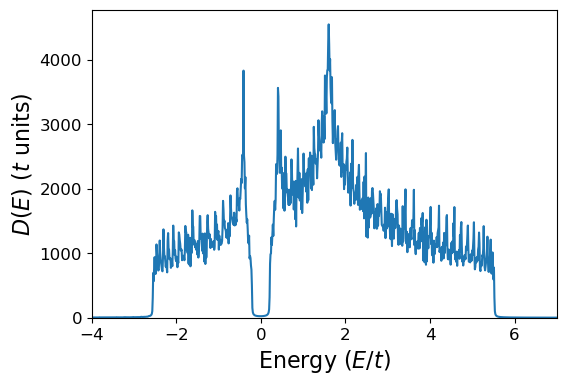

In [153]:
energies = np.linspace(-4,7,1000) 
dos_values = H.dos(energies, eta=0.005)
plt.figure(figsize=(6,4))
plt.plot(energies, dos_values)
plt.ylim(0, None)
plt.xlim(-4,7)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
# plt.text(2., 0.6, "(a)",fontsize=18, fontweight='bold', va='top', ha='left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [143]:
print(H.free_energy(0))

-12759.30024742434


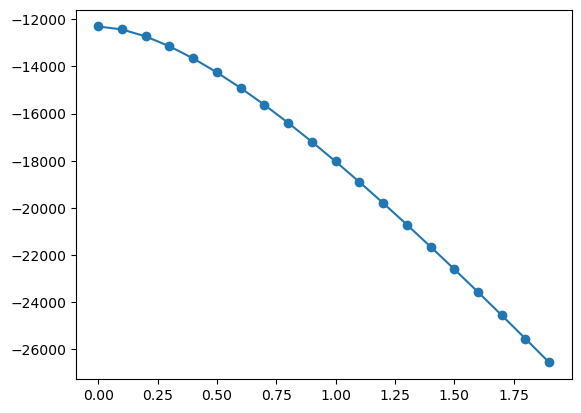

In [164]:
dxs = np.arange(0., 2, 0.1)
free = []
for dx in dxs:
    H = Hamiltonian(t,mu,lattice, U=U, V_prime=V, V=V, F0_init = dx)
    free.append(H.free_energy(0))

plt.figure()
plt.plot(dxs, free, '-o')

In [146]:
print(H.free_energy(0))

-19575.85173534906


In [147]:
# %prun H.dos(energies, eta=1e-3)